In [1]:
import networkx as nx
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Load the Marvel network
graphml_path = Path("marvel-network.graphml")
Graw = nx.read_graphml(graphml_path)
G = nx.Graph()
G.add_nodes_from(Graw.nodes(data=True))
for u, v, data in Graw.edges(data=True):
    if u != v:
        G.add_edge(u, v, **data)

print(f"Loaded network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Loaded network: 327 nodes, 9891 edges


In [3]:
# Create features for link prediction
def get_link_features(G, node1, node2):
    """Extract features for a potential link between two nodes"""
    features = {}
    
    # 1. Common neighbors (how many friends they share)
    common = len(list(nx.common_neighbors(G, node1, node2)))
    features['common_neighbors'] = common
    
    # 2. Jaccard coefficient (similarity of their neighborhoods)
    jaccard = list(nx.jaccard_coefficient(G, [(node1, node2)]))[0][2]
    features['jaccard_coefficient'] = jaccard
    
    # 3. Preferential attachment (product of their degrees)
    pref_attach = G.degree(node1) * G.degree(node2)
    features['preferential_attachment'] = pref_attach
    
    # 4. Degree difference (how different are they in popularity)
    deg_diff = abs(G.degree(node1) - G.degree(node2))
    features['degree_difference'] = deg_diff
    
    return features

In [4]:
# Generate training data
# Positive examples: existing edges
# Negative examples: non-existent edges

positive_edges = list(G.edges())
print(f"Positive examples (existing links): {len(positive_edges)}")

# Sample negative edges (same number as positive)
all_nodes = list(G.nodes())
negative_edges = []

while len(negative_edges) < len(positive_edges):
    node1 = np.random.choice(all_nodes)
    node2 = np.random.choice(all_nodes)
    
    if node1 != node2 and not G.has_edge(node1, node2):
        negative_edges.append((node1, node2))

print(f"Negative examples (non-existent links): {len(negative_edges)}")

Positive examples (existing links): 9891
Negative examples (non-existent links): 9891


In [5]:
# Build feature dataset
data = []

for u, v in positive_edges:
    features = get_link_features(G, u, v)
    features['link_exists'] = 1
    features['node1'] = u
    features['node2'] = v
    data.append(features)

for u, v in negative_edges:
    features = get_link_features(G, u, v)
    features['link_exists'] = 0
    features['node1'] = u
    features['node2'] = v
    data.append(features)

df = pd.DataFrame(data)
print(f"Total training examples: {len(df)}")
df.head()

Total training examples: 19782


,common_neighbors,jaccard_coefficient,preferential_attachment,degree_difference,link_exists,node1,node2
0,34,0.263566,6262,39,1,Black Panther / T'chal,Loki [asgardian]
1,23,0.223301,2525,76,1,Black Panther / T'chal,Mantis / ? Brandt
2,68,0.348718,16362,61,1,Black Panther / T'chal,Iceman / Robert Bobby
3,58,0.292929,15655,54,1,Black Panther / T'chal,Marvel Girl / Jean Grey
4,74,0.330357,19897,96,1,Black Panther / T'chal,Cyclops / Scott Summer


In [6]:
# Prepare features and labels
X = df[['common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 'degree_difference']]
y = df['link_exists']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} examples")
print(f"Test set: {len(X_test)} examples")

Training set: 15825 examples
Test set: 3957 examples


In [7]:
# Train Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Link', 'Link Exists']))

Accuracy: 0.8838

Classification Report:
              precision    recall  f1-score   support

     No Link       0.88      0.89      0.88      1958
 Link Exists       0.89      0.88      0.88      1999

    accuracy                           0.88      3957
   macro avg       0.88      0.88      0.88      3957
weighted avg       0.88      0.88      0.88      3957



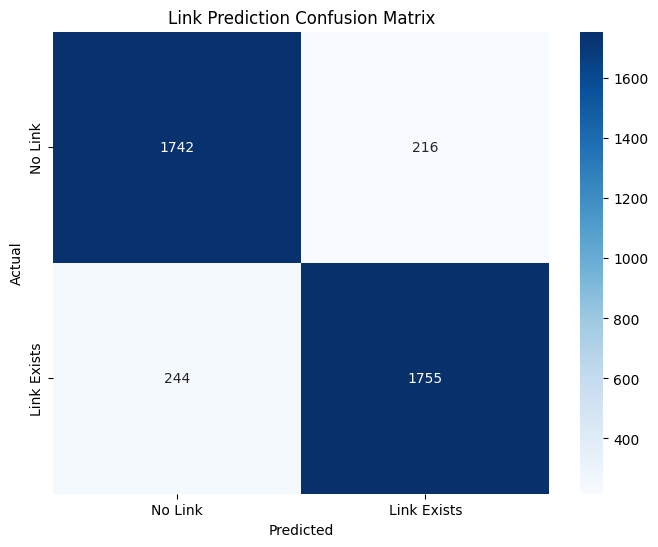

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Link', 'Link Exists'],
            yticklabels=['No Link', 'Link Exists'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Link Prediction Confusion Matrix')
plt.show()

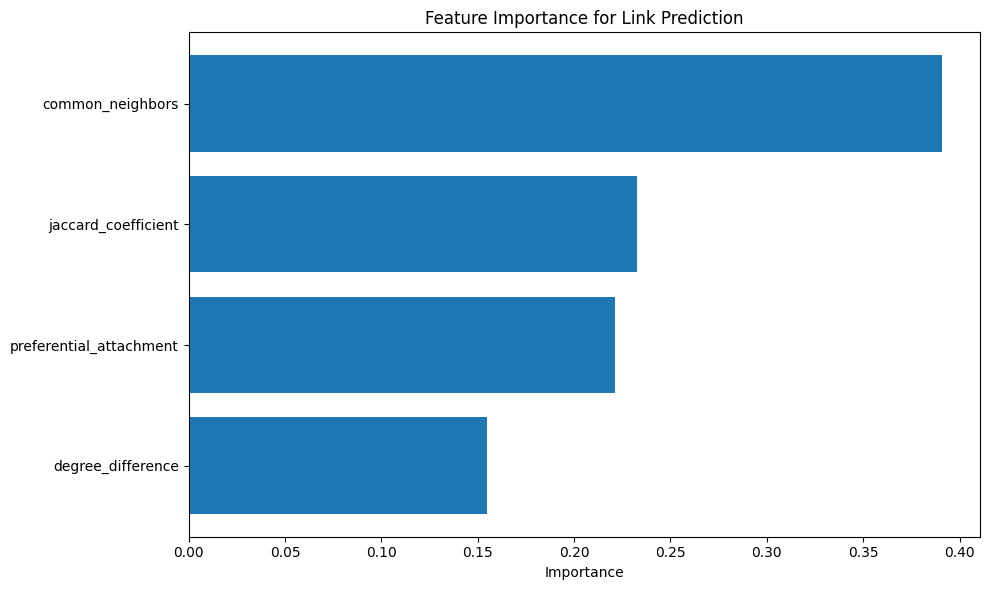


Feature Importance:
                   feature  importance
0         common_neighbors    0.391037
1      jaccard_coefficient    0.232828
2  preferential_attachment    0.221272
3        degree_difference    0.154863


In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Link Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)

In [12]:
# Predict new potential collaborations
# Find pairs of characters who DON'T currently have a link but MIGHT in the future

predictions = []
top_characters = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:50]  # Increased from 20 to 50
top_names = [name for name, _ in top_characters]

for i, node1 in enumerate(top_names):
    for node2 in top_names[i+1:]:
        if not G.has_edge(node1, node2):
            features = get_link_features(G, node1, node2)
            X_pred = pd.DataFrame([features])
            prob = model.predict_proba(X_pred)[0][1]  # Probability of link
            predictions.append({
                'character1': node1,
                'character2': node2,
                'probability': prob,
                'common_neighbors': features['common_neighbors']
            })

# Check if we found any predictions
if len(predictions) == 0:
    print("No potential collaborations found among top characters. They are all already connected!")
else:
    # Top 10 predicted future collaborations
    pred_df = pd.DataFrame(predictions).sort_values('probability', ascending=False).head(10)
    print("\n=== Top 10 Predicted Future Collaborations ===")
    print(pred_df.to_string(index=False))


=== Top 10 Predicted Future Collaborations ===
             character1              character2  probability  common_neighbors
 Nightcrawler / Kurt Wa   Black Knight V / Dane         0.97                77
  Dr. Strange / Stephen Magneto / Magnus / Eric         0.97                57
  Black Widow / Natasha   Shadowcat / Katherine         0.96                58
  Black Widow / Natasha    Polaris / Lorna Dane         0.96                69
 Ant-man / Dr. Henry J.   Shadowcat / Katherine         0.96                60
  Iron Man / Tony Stark    Havok / Alex Summers         0.95                78
 Sub-mariner / Namor Ma    Polaris / Lorna Dane         0.95                57
                   Hawk    Polaris / Lorna Dane         0.94                64
   Havok / Alex Summers     Fury, Col. Nicholas         0.94                54
Magneto / Magnus / Eric  Moondragon / Heather D         0.91                48
